# [1] Загрузка данных и анализ


In [177]:
# Настройки для полного отображения вывода
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [178]:
print("=" * 60)
print("1. ЗАГРУЗКА ДАННЫХ И АНАЛИЗ")
print("=" * 60)

# Загрузка данных
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
           'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 
           'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 
           'stalk-surface-below-ring', 'stalk-color-above-ring', 
           'stalk-color-below-ring', 'veil-type', 'veil-color', 
           'ring-number', 'ring-type', 'spore-print-color', 
           'population', 'habitat']

df = pd.read_csv(url, header=None, names=columns)
print(f"Размер dataset: {df.shape}")

1. ЗАГРУЗКА ДАННЫХ И АНАЛИЗ
Размер dataset: (8124, 23)


In [179]:
# Первичный осмотр данных
print("Первые 5 строк данных:")
display(df.head())

Первые 5 строк данных:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [180]:
print("\nИнформация о данных:")
print(df.info())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  st

In [181]:
print("\nРаспределение классов:")
class_distribution = df['class'].value_counts()
print(class_distribution)


Распределение классов:
class
e    4208
p    3916
Name: count, dtype: int64


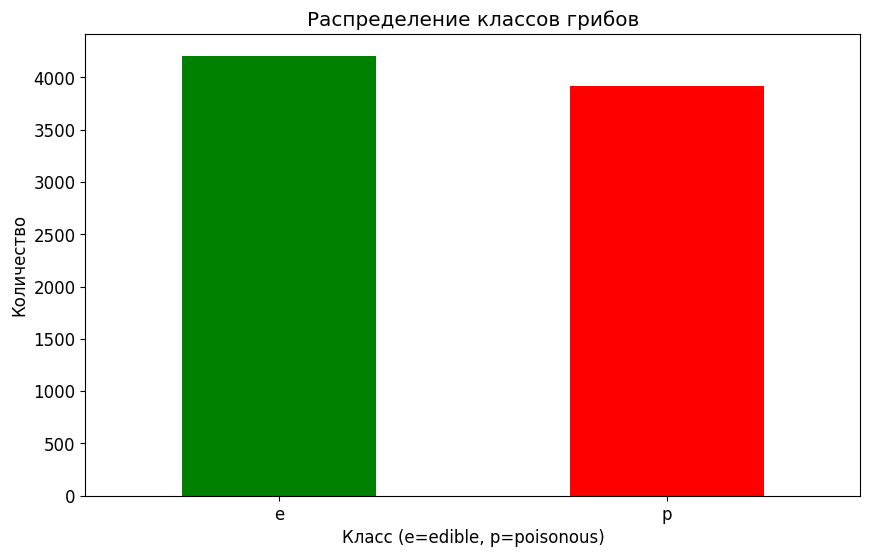

In [206]:
# Визуализация распределения классов
plt.figure(figsize=(10, 6))
class_distribution.plot(kind='bar', color=['green', 'red'])
plt.title('Распределение классов грибов')
plt.xlabel('Класс (e=edible, p=poisonous)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.show()

# [2] Визуализация респрделений признаков 

Визуализация распределений признаков по классам


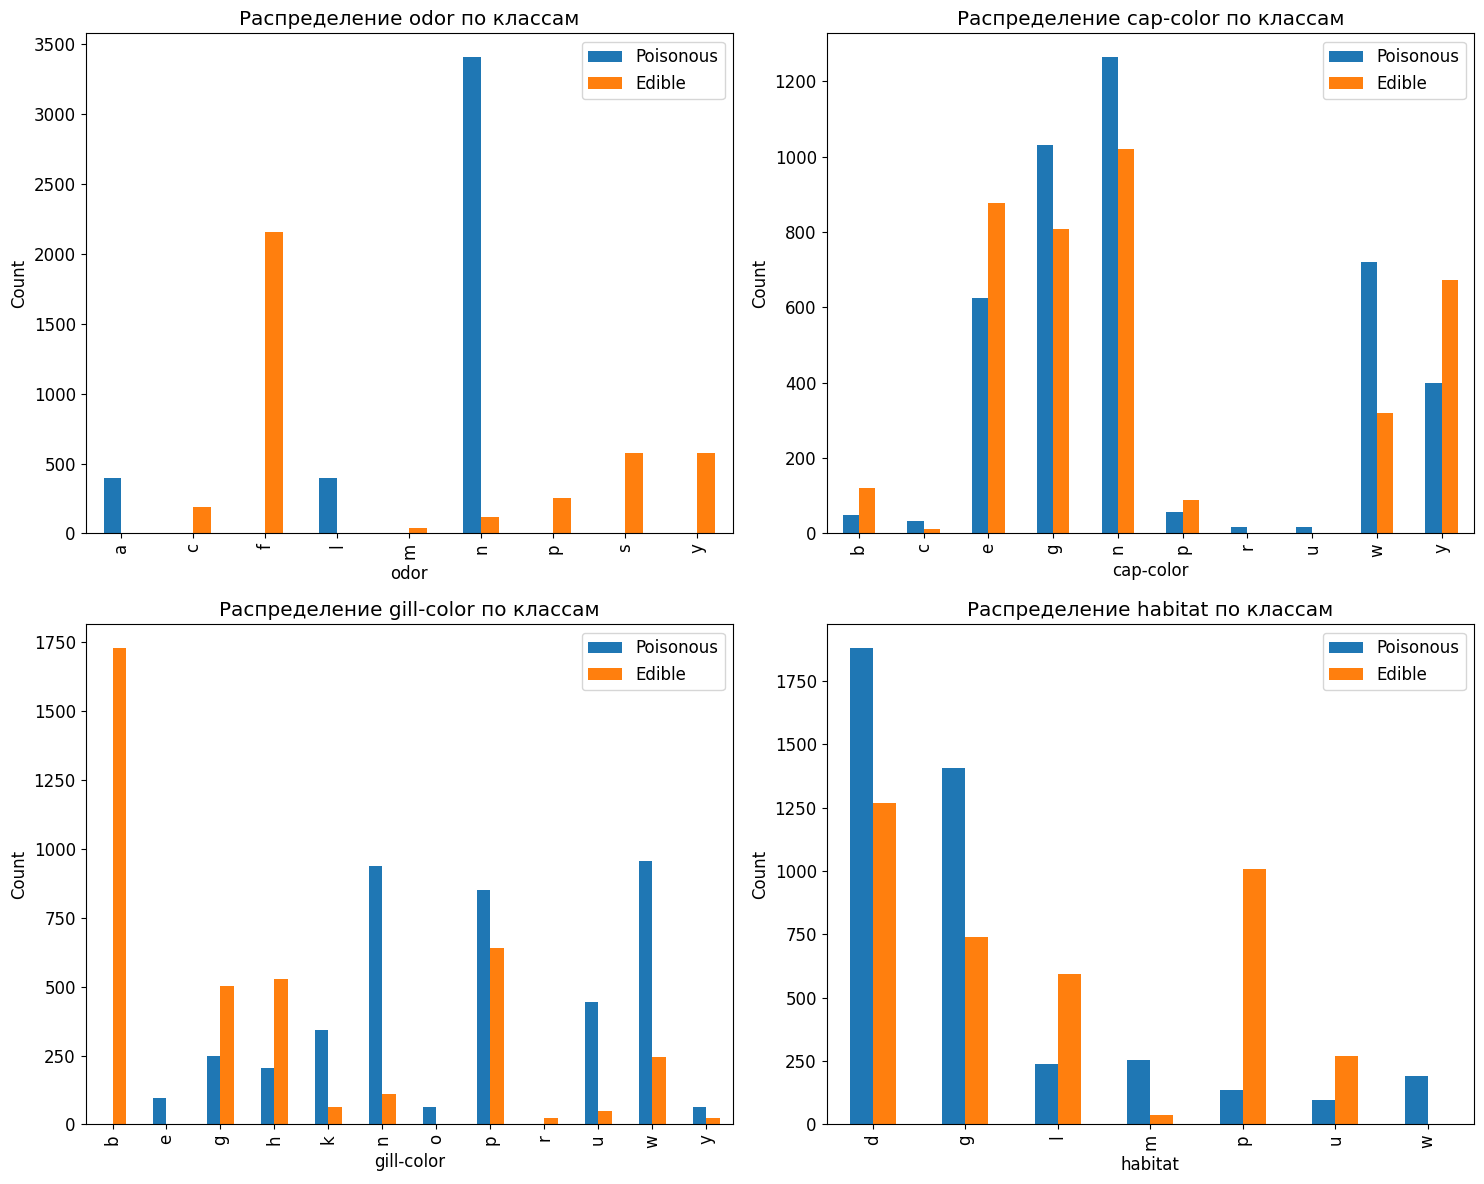

In [183]:
print("Визуализация распределений признаков по классам")
# Создаем подграфики для нескольких признаков
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
features_to_plot = ['odor', 'cap-color', 'gill-color', 'habitat']

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    cross_tab = pd.crosstab(df[feature], df['class'])
    cross_tab.plot(kind='bar', ax=ax)
    ax.set_title(f'Распределение {feature} по классам')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend(['Poisonous', 'Edible'])

plt.tight_layout()
plt.show()

# [3] Анализ отдельных признаков

In [184]:
print("Анализ распределения значений по признакам")
for feature in ['odor', 'cap-color', 'habitat']:
    print(f"\n{feature}:")
    print(pd.crosstab(df[feature], df['class'], normalize='columns'))

Анализ распределения значений по признакам

odor:
class         e         p
odor                     
a      0.095057  0.000000
c      0.000000  0.049030
f      0.000000  0.551583
l      0.095057  0.000000
m      0.000000  0.009193
n      0.809886  0.030644
p      0.000000  0.065373
s      0.000000  0.147089
y      0.000000  0.147089

cap-color:
class             e         p
cap-color                    
b          0.011407  0.030644
c          0.007605  0.003064
e          0.148289  0.223698
g          0.245247  0.206333
n          0.300380  0.260470
p          0.013308  0.022472
r          0.003802  0.000000
u          0.003802  0.000000
w          0.171103  0.081716
y          0.095057  0.171604

habitat:
class           e         p
habitat                    
d        0.446768  0.323800
g        0.334601  0.188968
l        0.057034  0.151175
m        0.060837  0.009193
p        0.032319  0.257406
u        0.022814  0.069459
w        0.045627  0.000000


# [4] Решающие функции по каждой переменной

In [207]:
# Подготовка данных
X = df.drop('class', axis=1)
y = df['class']

# Функция для построения решающей функции по одной переменной
def single_feature_classifier(X_feature, y):
    prob_table = pd.crosstab(X_feature, y, normalize='index')
    predictions = prob_table.idxmax(axis=1)
    prediction_map = predictions.to_dict()
    y_pred = X_feature.map(prediction_map)
    accuracy = accuracy_score(y, y_pred)
    return accuracy, prob_table, prediction_map

In [186]:
# Тестируем все признаки
feature_accuracies = {}
best_feature = None
best_accuracy = 0

print("Точность классификации по отдельным признакам:")
print("-" * 50)

for feature in X.columns:
    accuracy, prob_table, _ = single_feature_classifier(X[feature], y)
    feature_accuracies[feature] = accuracy
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_feature = feature
    
    print(f"{feature:25}: {accuracy:.4f}")

print("-" * 50)
print(f"Наиболее информативный признак: {best_feature}")
print(f"Точность: {best_accuracy:.4f}")

Точность классификации по отдельным признакам:
--------------------------------------------------
cap-shape                : 0.5643
cap-surface              : 0.5805
cap-color                : 0.5953
bruises                  : 0.7440
odor                     : 0.9852
gill-attachment          : 0.5180
gill-spacing             : 0.6160
gill-size                : 0.7563
gill-color               : 0.8050
stalk-shape              : 0.5529
stalk-root               : 0.6460
stalk-surface-above-ring : 0.7745
stalk-surface-below-ring : 0.7661
stalk-color-above-ring   : 0.7164
stalk-color-below-ring   : 0.7144
veil-type                : 0.5180
veil-color               : 0.5190
ring-number              : 0.5382
ring-type                : 0.7755
spore-print-color        : 0.8680
population               : 0.7218
habitat                  : 0.6903
--------------------------------------------------
Наиболее информативный признак: odor
Точность: 0.9852


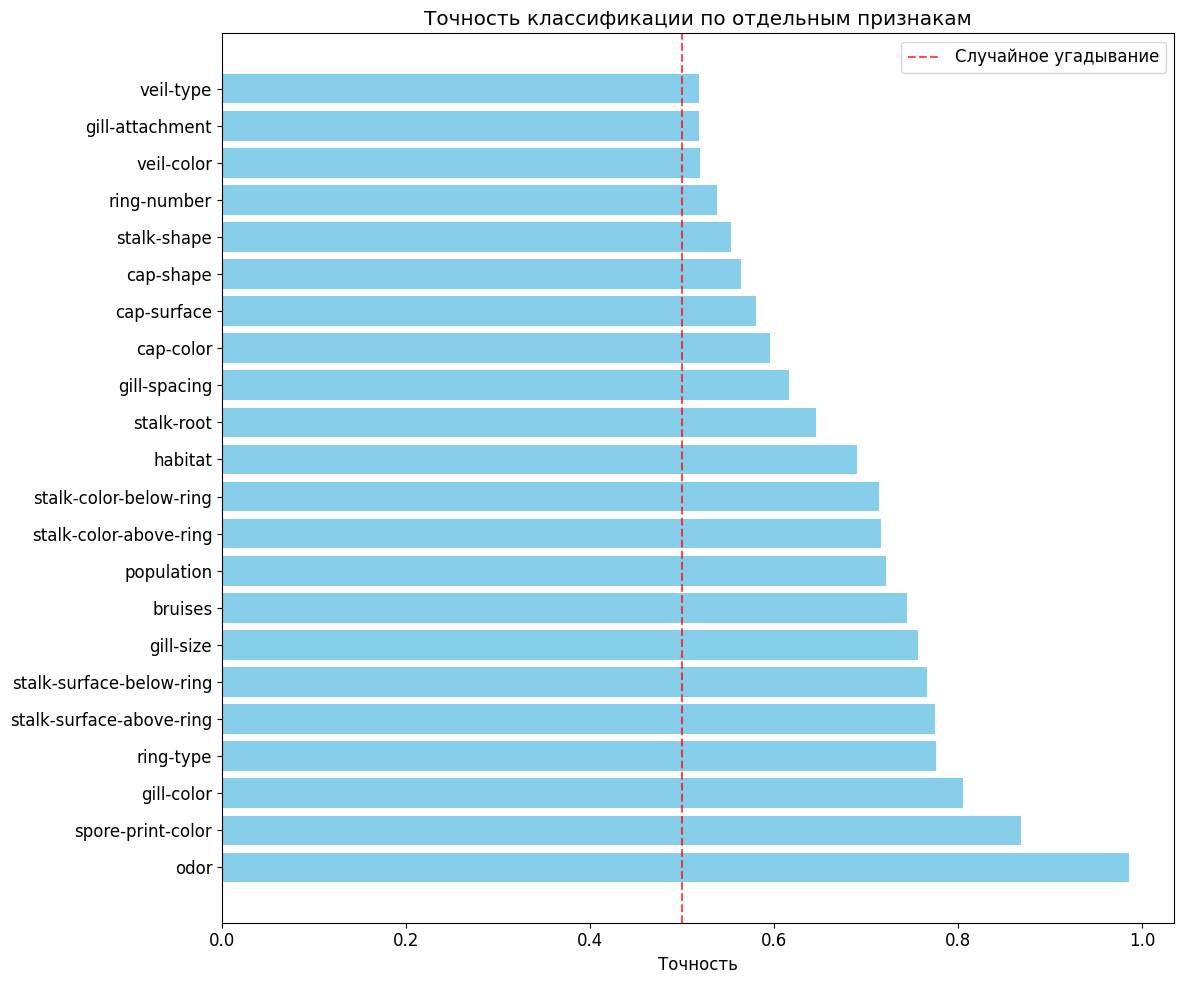

In [187]:
# Визуализация точности по признакам
plt.figure(figsize=(12, 10))
features_sorted = sorted(feature_accuracies.items(), key=lambda x: x[1], reverse=True)
features_names = [f[0] for f in features_sorted]
features_scores = [f[1] for f in features_sorted]

plt.barh(features_names, features_scores, color='skyblue')
plt.xlabel('Точность')
plt.title('Точность классификации по отдельным признакам')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Случайное угадывание')
plt.legend()
plt.tight_layout()
plt.show()

# [5] Наивный Байес из sklearn

In [188]:
print("\n" + "=" * 60)
print("3. НАИВНЫЙ БАЙЕС ИЗ SKLEARN")
print("=" * 60)

# Кодируем категориальные переменные
label_encoders = {}
X_encoded = X.copy()

for column in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[column] = le.fit_transform(X_encoded[column].astype(str))
    label_encoders[column] = le

# Кодируем целевую переменную
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Классы целевой переменной:", le_target.classes_)
print("Закодированные значения:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))


3. НАИВНЫЙ БАЙЕС ИЗ SKLEARN
Классы целевой переменной: ['e' 'p']
Закодированные значения: {'e': np.int64(0), 'p': np.int64(1)}


In [189]:
# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, 
                                                    test_size=0.3, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (5686, 22)
Размер тестовой выборки: (2438, 22)


In [190]:
# Обучаем наивный Байес
nb_sklearn = CategoricalNB()
nb_sklearn.fit(X_train, y_train)

# Предсказания и оценка
y_pred_sklearn = nb_sklearn.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Точность наивного Байеса (sklearn): {accuracy_sklearn:.4f}")

Точность наивного Байеса (sklearn): 0.9459


In [191]:
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_sklearn, 
                          target_names=le_target.classes_))


Отчет по классификации:
              precision    recall  f1-score   support

           e       0.91      1.00      0.95      1257
           p       1.00      0.89      0.94      1181

    accuracy                           0.95      2438
   macro avg       0.95      0.94      0.95      2438
weighted avg       0.95      0.95      0.95      2438



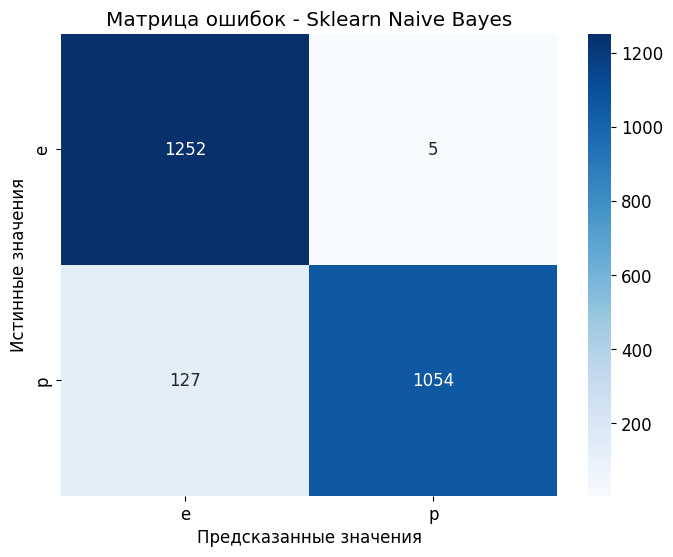

In [192]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_sklearn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Матрица ошибок - Sklearn Naive Bayes')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# [6] Собственная реализация наивного Байеса

In [208]:
class CustomNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # параметр регуляризации
        self.class_probs = None
        self.feature_probs = None
        self.classes = None
        
    def fit(self, X, y):
        # Преобразуем в numpy arrays
        X_np = X.values if hasattr(X, 'values') else X
        y_np = y.values if hasattr(y, 'values') else y
        
        self.classes = np.unique(y_np)
        n_samples, n_features = X_np.shape
        
        print(f"Обучение модели на {n_samples} samples, {n_features} признаков")
        print(f"Классы: {self.classes}")
        
        # Априорные вероятности классов
        self.class_probs = {}
        total_samples = len(y_np)
        for c in self.classes:
            class_count = np.sum(y_np == c)
            self.class_probs[c] = class_count / total_samples
            print(f"P(class={c}) = {self.class_probs[c]:.4f} ({class_count} samples)")
        
        # Условные вероятности признаков
        self.feature_probs = {}
        
        for feature_idx in range(n_features):
            self.feature_probs[feature_idx] = {}
            feature_values = X_np[:, feature_idx]
            unique_values = np.unique(feature_values)
            
            print(f"Признак {feature_idx}: {len(unique_values)} уникальных значений")
            
            for c in self.classes:
                # Индексы samples этого класса
                class_indices = np.where(y_np == c)[0]
                class_samples_count = len(class_indices)
                
                if class_samples_count == 0:
                    # Если нет samples этого класса, используем равномерное распределение
                    value_probs = {value: 1.0 / len(unique_values) for value in unique_values}
                else:
                    # Значения признака для этого класса
                    class_feature_values = X_np[class_indices, feature_idx]
                    
                    # Считаем вероятности с регуляризацией Лапласа
                    value_probs = {}
                    for value in unique_values:
                        value_count = np.sum(class_feature_values == value)
                        value_probs[value] = (value_count + self.alpha) / (class_samples_count + self.alpha * len(unique_values))
                
                self.feature_probs[feature_idx][c] = value_probs
                
            # Покажем информацию о первом классе для отладки
            if feature_idx < 2:  # Только для первых 2 признаков
                first_class = self.classes[0]
                sample_probs = list(self.feature_probs[feature_idx][first_class].items())[:3]
                print(f"  Пример для класса {first_class}: {sample_probs}")
    
    def predict_proba(self, X):
        """Возвращает вероятности классов"""
        X_np = X.values if hasattr(X, 'values') else X
        
        n_samples = X_np.shape[0]
        n_classes = len(self.classes)
        probabilities = np.zeros((n_samples, n_classes))
        
        for i in range(n_samples):
            sample = X_np[i]
            class_scores = np.zeros(n_classes)
            
            for j, c in enumerate(self.classes):
                # Логарифм априорной вероятности
                score = np.log(self.class_probs[c])
                
                # Сумма логарифмов условных вероятностей
                for feature_idx, feature_value in enumerate(sample):
                    feature_prob_dict = self.feature_probs[feature_idx][c]
                    
                    if feature_value in feature_prob_dict:
                        prob = feature_prob_dict[feature_value]
                    else:
                        # Если значение не встречалось при обучении
                        n_unique = len(feature_prob_dict)
                        prob = self.alpha / (len(feature_prob_dict) + self.alpha * n_unique)
                    
                    score += np.log(max(prob, 1e-10))  # Защита от log(0)
                
                class_scores[j] = score
            
            # Преобразуем логарифмы в вероятности
            # Используем softmax для численной стабильности
            max_score = np.max(class_scores)
            exp_scores = np.exp(class_scores - max_score)
            probabilities[i] = exp_scores / np.sum(exp_scores)
        
        return probabilities
    
    def predict(self, X):
        """Возвращает предсказанные классы"""
        probabilities = self.predict_proba(X)
        return self.classes[np.argmax(probabilities, axis=1)]

In [194]:
# Тестируем собственную реализацию
print("Создание и обучение модели...")
custom_nb = CustomNaiveBayes(alpha=1.0)

print("\nОбучение модели:")
custom_nb.fit(X_train, y_train)

print("\nПредсказание на тестовой выборке...")
y_pred_custom = custom_nb.predict(X_test)
accuracy_custom = accuracy_score(y_test, y_pred_custom)

print(f"\nТочность собственной реализации: {accuracy_custom:.4f}")

Создание и обучение модели...

Обучение модели:
Обучение модели на 5686 samples, 22 признаков
Классы: [0 1]
P(class=0) = 0.5190 (2951 samples)
P(class=1) = 0.4810 (2735 samples)
Признак 0: 6 уникальных значений
  Пример для класса 0: [(np.int64(0), np.float64(0.09029421711193777)), (np.int64(1), np.float64(0.00033818058843422386)), (np.int64(2), np.float64(0.3807913425769361))]
Признак 1: 4 уникальных значений
  Пример для класса 0: [(np.int64(0), np.float64(0.3692047377326565)), (np.int64(1), np.float64(0.00033840947546531303)), (np.int64(2), np.float64(0.2734348561759729))]
Признак 2: 10 уникальных значений
Признак 3: 2 уникальных значений
Признак 4: 9 уникальных значений
Признак 5: 2 уникальных значений
Признак 6: 2 уникальных значений
Признак 7: 2 уникальных значений
Признак 8: 12 уникальных значений
Признак 9: 2 уникальных значений
Признак 10: 5 уникальных значений
Признак 11: 4 уникальных значений
Признак 12: 4 уникальных значений
Признак 13: 9 уникальных значений
Признак 14: 9 у

In [195]:
print("\nОтчет по классификации (собственная реализация):")
print(classification_report(y_test, y_pred_custom, 
                          target_names=le_target.classes_))


Отчет по классификации (собственная реализация):
              precision    recall  f1-score   support

           e       0.91      1.00      0.95      1257
           p       1.00      0.89      0.94      1181

    accuracy                           0.95      2438
   macro avg       0.95      0.94      0.95      2438
weighted avg       0.95      0.95      0.95      2438



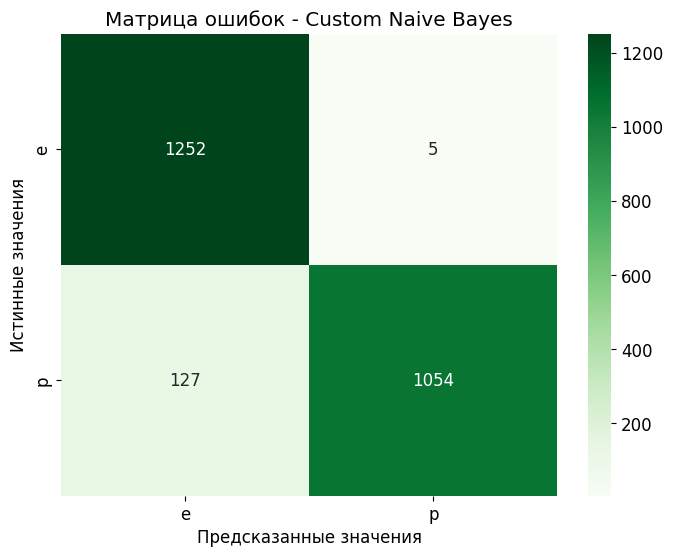

In [196]:
# Матрица ошибок для собственной реализации
cm_custom = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Матрица ошибок - Custom Naive Bayes')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [197]:
# Сравнение реализаций
print("\nСравнение реализаций:")
print(f"Sklearn Naive Bayes:    {accuracy_sklearn:.4f}")
print(f"Custom Naive Bayes:     {accuracy_custom:.4f}")
print(f"Разница:                {abs(accuracy_sklearn - accuracy_custom):.4f}")


Сравнение реализаций:
Sklearn Naive Bayes:    0.9459
Custom Naive Bayes:     0.9459
Разница:                0.0000


# [7] Логистическая регрессия с преобразованными вероятностями

In [198]:
print("\n" + "=" * 80)
print("5. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ С ПРЕОБРАЗОВАННЫМИ ВЕРОЯТНОСТЯМИ")
print("=" * 80)

# Упрощенная функция для вычисления вероятностей признаков
def get_feature_probabilities_simple(X, y):
    """Вычисляет вероятности классов для каждого значения признака"""
    feature_probs = {}
    
    # Преобразуем в numpy для простоты
    X_np = X.to_numpy() if hasattr(X, 'to_numpy') else np.array(X)
    y_np = y.to_numpy() if hasattr(y, 'to_numpy') else np.array(y)
    
    n_features = X_np.shape[1]
    
    for feature_idx in range(n_features):
        feature_probs[feature_idx] = {}
        feature_values = X_np[:, feature_idx]
        unique_values = np.unique(feature_values)
        
        for value in unique_values:
            # Маска для текущего значения признака
            value_mask = (feature_values == value)
            if np.sum(value_mask) > 0:
                # Вероятность класса 1 для этого значения признака
                prob_class_1 = np.sum(y_np[value_mask] == 1) / np.sum(value_mask)
                feature_probs[feature_idx][value] = prob_class_1
    
    return feature_probs

# Альтернативный подход - используем группировку pandas
def get_feature_probabilities_pandas(X, y):
    """Вычисляет вероятности используя pandas группировку"""
    feature_probs = {}
    
    # Объединяем X и y в один DataFrame для удобства
    data = X.copy()
    data['target'] = y
    
    for feature in X.columns:
        feature_probs[feature] = {}
        
        # Группируем по значениям признака и вычисляем среднее целевой переменной
        grouped = data.groupby(feature)['target'].mean()
        
        for value, prob in grouped.items():
            feature_probs[feature][value] = prob
    
    return feature_probs

print("Вычисление вероятностей признаков...")
# Используем pandas подход
feature_probs = get_feature_probabilities_pandas(X_train, y_train)

print("Пример вероятностей для первых 3 признаков:")
for i, feature in enumerate(list(X_train.columns)[:3]):
    print(f"\n{feature}:")
    feature_probs_subset = dict(list(feature_probs[feature].items())[:5])  # Первые 5 значений
    for value, prob in feature_probs_subset.items():
        print(f"  '{value}': {prob:.3f}")


5. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ С ПРЕОБРАЗОВАННЫМИ ВЕРОЯТНОСТЯМИ
Вычисление вероятностей признаков...
Пример вероятностей для первых 3 признаков:

cap-shape:
  '0': 0.125
  '1': 1.000
  '2': 0.486
  '3': 0.719
  '4': 0.000

cap-surface:
  '0': 0.328
  '1': 1.000
  '2': 0.549
  '3': 0.536

cap-color:
  '0': 0.694
  '1': 0.297
  '2': 0.586
  '3': 0.435
  '4': 0.445


In [199]:
# Создаем новую матрицу признаков на основе вероятностей
print("\nСоздание матрицы вероятностных признаков...")

X_train_probs = np.zeros((X_train.shape[0], X_train.shape[1]))
X_test_probs = np.zeros((X_test.shape[0], X_test.shape[1]))

# Заполняем матрицы вероятностями
for i, feature in enumerate(X_train.columns):
    # Для обучающей выборки
    for j in range(X_train.shape[0]):
        value = X_train.iloc[j, i]
        if value in feature_probs[feature]:
            X_train_probs[j, i] = feature_probs[feature][value]
        else:
            X_train_probs[j, i] = 0.5  # нейтральное значение
    
    # Для тестовой выборки
    for j in range(X_test.shape[0]):
        value = X_test.iloc[j, i]
        if value in feature_probs[feature]:
            X_test_probs[j, i] = feature_probs[feature][value]
        else:
            X_test_probs[j, i] = 0.5

print(f"Размер X_train_probs: {X_train_probs.shape}")
print(f"Размер X_test_probs: {X_test_probs.shape}")
print(f"Пример первых 5 строк X_train_probs:")
print(X_train_probs[:5, :5])


Создание матрицы вероятностных признаков...
Размер X_train_probs: (5686, 22)
Размер X_test_probs: (2438, 22)
Пример первых 5 строк X_train_probs:
[[0.46578021 0.54916201 0.69354839 0.17935702 1.        ]
 [0.46578021 0.32840419 0.43485086 0.17935702 0.03246493]
 [0.46578021 0.32840419 0.43485086 0.69566526 1.        ]
 [0.46578021 0.53588727 0.64217687 0.17935702 0.        ]
 [0.46578021 0.53588727 0.44465291 0.69566526 1.        ]]


In [200]:
# Применяем обратное логистическое преобразование (logit)
def safe_logit(p, epsilon=1e-15):
    """Безопасное логит-преобразование с защитой от крайних значений"""
    p = np.clip(p, epsilon, 1 - epsilon)
    return np.log(p / (1 - p))

X_train_logit = safe_logit(X_train_probs)
X_test_logit = safe_logit(X_test_probs)

print("Пример logit-преобразованных признаков (первые 5 строк):")
print(X_train_logit[:5, :5])

Пример logit-преобразованных признаков (первые 5 строк):
[[ -0.13709347   0.19728545   0.81676114  -1.5207098   34.53957599]
 [ -0.13709347  -0.71541155  -0.26208653  -1.5207098   -3.39459125]
 [ -0.13709347  -0.71541155  -0.26208653   0.82674039  34.53957599]
 [ -0.13709347   0.14379636   0.58482495  -1.5207098  -34.53877639]
 [ -0.13709347   0.14379636  -0.22229931   0.82674039  34.53957599]]


In [201]:
# Обучаем логистическую регрессию
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_logit, y_train)

# Предсказания и оценка
y_pred_logreg = logreg.predict(X_test_logit)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)

print(f"Точность логистической регрессии: {accuracy_logreg:.4f}")

Точность логистической регрессии: 0.9996


In [202]:
print("\nОтчет по классификации (логистическая регрессия):")
print(classification_report(y_test, y_pred_logreg, 
                          target_names=le_target.classes_))


Отчет по классификации (логистическая регрессия):
              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1257
           p       1.00      1.00      1.00      1181

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



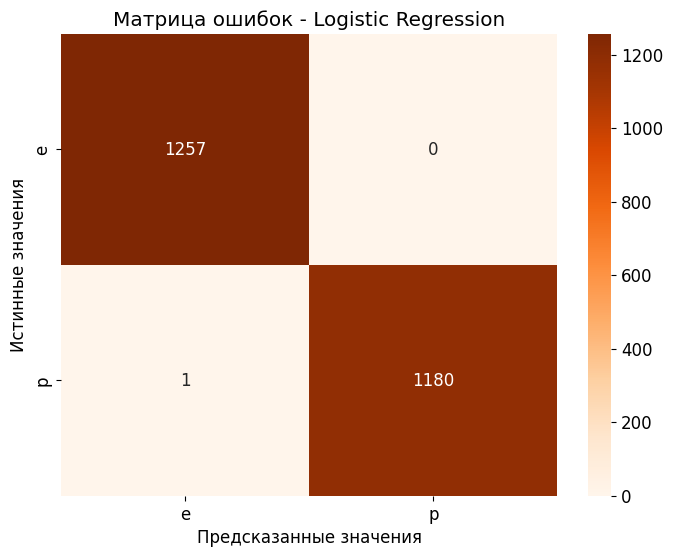

In [203]:
# Матрица ошибок для логистической регрессии
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Матрица ошибок - Logistic Regression')
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

# [8] Итоговое сравнение методов

In [204]:
print("\n" + "=" * 60)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ")
print("=" * 60)

methods = ['Лучший одиночный признак', 'Sklearn Naive Bayes', 
           'Custom Naive Bayes', 'Logistic Regression']
accuracies = [best_accuracy, accuracy_sklearn, accuracy_custom, accuracy_logreg]

comparison_df = pd.DataFrame({
    'Метод': methods,
    'Точность': accuracies
})

display(comparison_df)


ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ


,Метод,Точность
0,Лучший одиночный признак,0.985229
1,Sklearn Naive Bayes,0.945857
2,Custom Naive Bayes,0.945857
3,Logistic Regression,0.999590


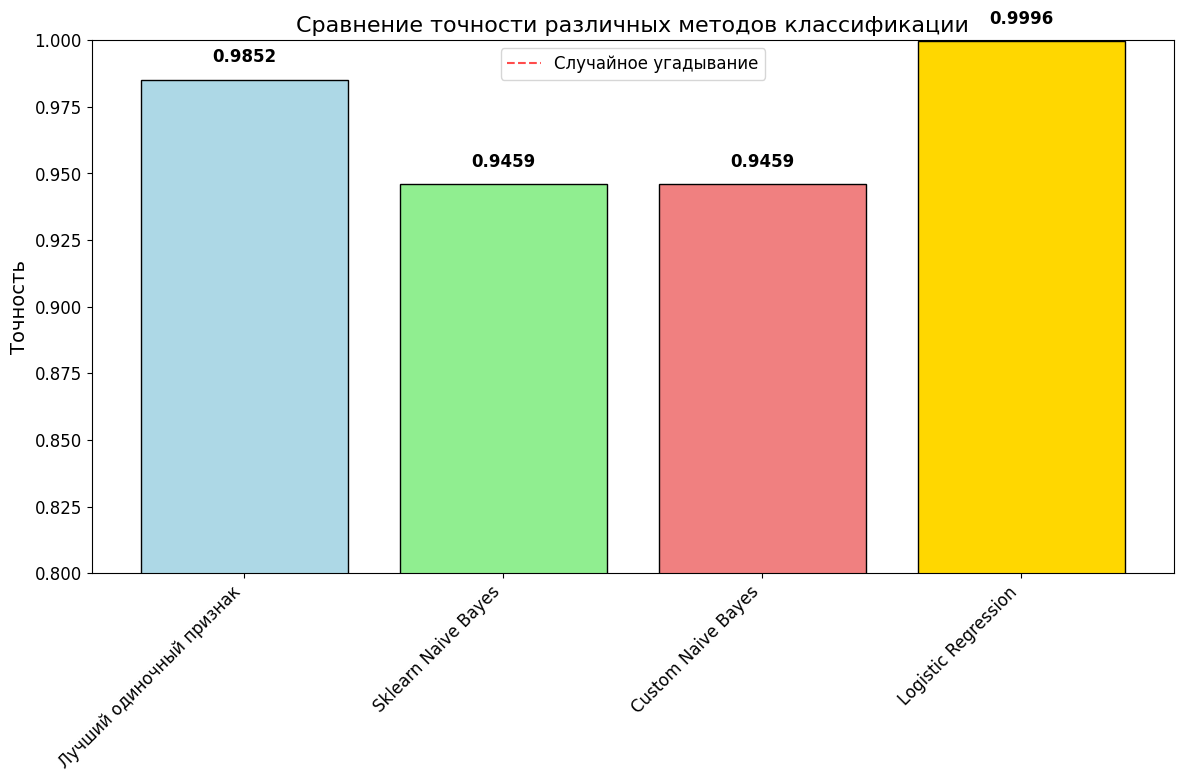

In [205]:
# Визуализация сравнения методов
plt.figure(figsize=(12, 8))
colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold']
bars = plt.bar(methods, accuracies, color=colors, edgecolor='black')

plt.ylim(0.8, 1.0)
plt.ylabel('Точность', fontsize=14)
plt.title('Сравнение точности различных методов классификации', fontsize=16)
plt.xticks(rotation=45, ha='right')

# Добавляем значения на столбцы
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{accuracy:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Добавляем горизонтальную линию для случайного угадывания
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Случайное угадывание')
plt.legend()

plt.tight_layout()
plt.show()